&#x1f12f; Lucas Estevao Bazilio - Digitalització 1r DAM/CIDE/25-26

In [8]:
# Descomentar para actualizar librerias
# Si se actualiza alguna libreria hay que reiniciar el notebook
#!pip install pandas --upgrade --user --quiet
#!pip install numpy --upgrade --user --quiet
#!pip install scipy --upgrade --user --quiet
#!pip install scikit-learn --upgrade --user --quiet
#!pip install missingno --upgrade --user --quiet
# versionesmodernas pero compatibles con Colab
!pip install "pandas==2.2.2" "numpy<2.1.0" scipy scikit-learn missingno --upgrade --quiet

In [9]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
from sklearn import datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set()
import pandas as pd

from sklearn import set_config
import warnings

set_config(display='text')
warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)

from mpl_toolkits.mplot3d import Axes3D

from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding, TSNE


# Ejercicio práctico de visualización

En este ejercicio trabajaremos con el conjunto de datos preprocesado en la primera sesion de laboratorio.

Encontraréis los datos preprocesados de Titanic entre el material de esta sesion (conjunto de entrenamiento), o podeis coger los datos que grabasteis en la sesión pasada.



Debéis aplicar los siguientes pasos:
- [ ] Aplicar PCA
- [ ] Gráfica de la varianza explicada por cada componente de PCA
- [ ] Representar los pesos de los componentes
- [ ] Visualizar los datos con PCA en 2/3D
- [ ] Aplicar LLE y visualizar los datos en 2/3D
- [ ] Aplicar t-SNE y visualizar los datos en 2/3D


**0. Preparación de datos**


In [10]:
# Importanción CSV desde drive
import io
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


Objetivo: separar los mas de 1000 individuos en 6 clases en una matríz 3x3 según su clase y si sobrevivió



In [32]:
titanic_data = pd.read_csv("titanic.csv", header=0)
#leemos los datos
#renombramos algunas columnas para mejorar la legibilidad
titanic_data = titanic_data.rename(columns={'pclass':'socialClass', 'sibsp':'number of siblings', 'home.dest':'destination',})

#mapeamos los datos segun clase social y si sobrevivió
titanic_data['socialClass'] = titanic_data['socialClass'].map({1:'First', 2:'Second', 3:'Third'})
titanic_data['survived'] = titanic_data['survived'].map({1:'Yes', 0:'No'})

#mostramos los datos
titanic_data.describe(include='all')
titanic_data.head()

,socialClass,survived,name,sex,age,number of siblings,parch,ticket,fare,cabin,embarked,boat,body,destination
count,1309,1309,1309,1309,1046.000,1309.000,1309.000,1309,1308.000,295,1307,486,121.000,745
unique,3,2,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369
top,Third,No,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,709,809,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,NaN,NaN,NaN,NaN,29.881,0.499,0.385,NaN,33.295,NaN,NaN,NaN,160.810,NaN
std,NaN,NaN,NaN,NaN,14.413,1.042,0.866,NaN,51.759,NaN,NaN,NaN,97.697,NaN
min,NaN,NaN,NaN,NaN,0.167,0.000,0.000,NaN,0.000,NaN,NaN,NaN,1.000,NaN
25%,NaN,NaN,NaN,NaN,21.000,0.000,0.000,NaN,7.896,NaN,NaN,NaN,72.000,NaN
50%,NaN,NaN,NaN,NaN,28.000,0.000,0.000,NaN,14.454,NaN,NaN,NaN,155.000,NaN
75%,NaN,NaN,NaN,NaN,39.000,1.000,0.000,NaN,31.275,NaN,NaN,NaN,256.000,NaN


,socialClass,survived,name,sex,age,number of siblings,parch,ticket,fare,cabin,embarked,boat,body,destination
0,First,Yes,"Allen, Miss. Elisabeth Walton",female,29.000,0,0,24160,211.338,B5,S,2,NaN,"St Louis, MO"
1,First,Yes,"Allison, Master. Hudson Trevor",male,0.917,1,2,113781,151.550,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,First,No,"Allison, Miss. Helen Loraine",female,2.000,1,2,113781,151.550,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,First,No,"Allison, Mr. Hudson Joshua Creighton",male,30.000,1,2,113781,151.550,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,First,No,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.000,1,2,113781,151.550,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [34]:
#definimos una columna igual a la clase social + si ha sobrevivido
titanic_data['class'] =  titanic_data.socialClass + " " + titanic_data.survived
# segunda columna gual al valor total + ordenador
titanic_data['class'].value_counts().sort_index()

,count
class,
First No,123
First Yes,200
Second No,158
Second Yes,119
Third No,528
Third Yes,181


<Axes: xlabel='value', ylabel='variable'>

<Axes: xlabel='value', ylabel='variable'>

Text(0.5, 1.0, 'Distribución de Edad y Tarifa por Clase Social y Supervivencia')

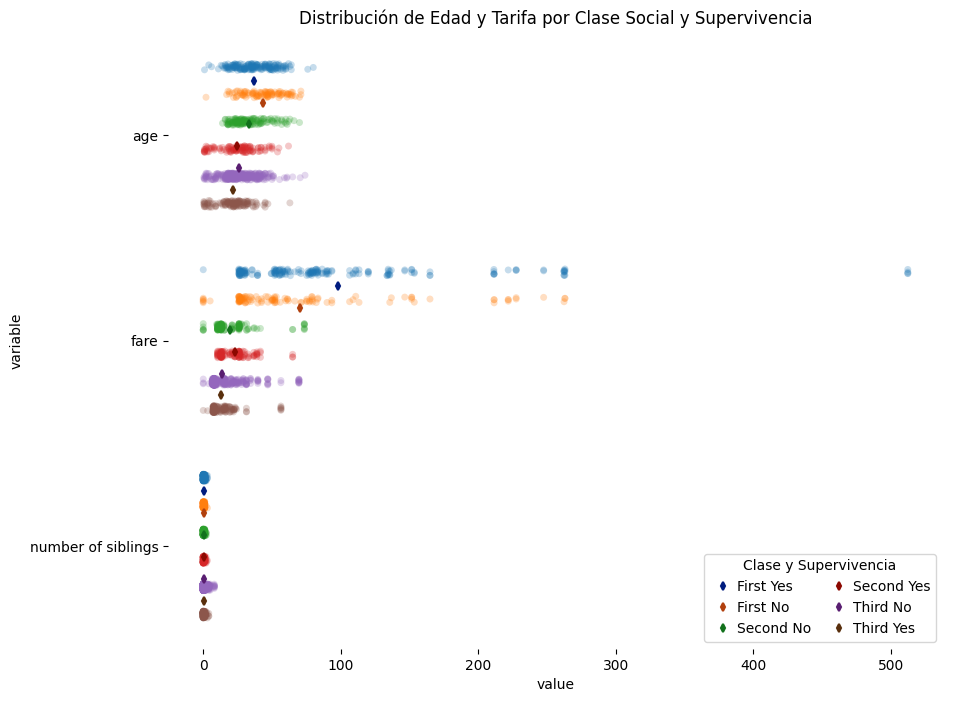

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las variables numéricas que queremos comparar
#en este caso edad, tarifa y numero de familiares en el mismo trayecto
titanic_num_vars = ['age', 'fare', 'number of siblings']

# "Derretimos" el DataFrame para Seaborn
df_titanic_melt = pd.melt(titanic_data, id_vars=['class'], value_vars=titanic_num_vars)

#Creación del gráfico
f, ax = plt.subplots(figsize=(10, 8))
sns.despine(bottom=True, left=True)

# Dibujamos los puntos
sns.stripplot(x="value", y="variable", hue="class", data=df_titanic_melt,
              dodge=True, alpha=.25, zorder=1)

# Dibujamos el punto medio y el intervalo
sns.pointplot(x="value", y="variable", hue="class", data=df_titanic_melt,
              dodge=.8 - .8 / 3, join=False, palette="dark",
              markers="d", scale=.75, ci=None)

# leyenda
handles, labels = ax.get_legend_handles_labels()
# En el Titanic hay 6 clases
# Por eso ajustamos el índice de la leyenda para que no se duplique
ax.legend(handles[6:], labels[6:], title="Clase y Supervivencia",
          handletextpad=0, columnspacing=1, loc="lower right", ncol=2, frameon=True)

plt.title("Distribución de Edad y Tarifa por Clase Social y Supervivencia")
plt.show()

# Cada puntito pequeño y semi-transparente es un pasajero real del Titanic
# El punto medio representa la Media (Promedio).
# La línea representa el intervalo y/o dispersión de datos

Exploración básica de los datos

In [39]:
#cargamos las columnas con datos más interesantes y de los cuales podemos deducir más información
data_columns = ['age','number of siblings','parch','cabin','fare']
titanic_data[data_columns].describe()
#count valores no nulos en esa columna

# mean (Media o Promedio) suma de todos los valores dividida por el número total de filas.

#  std qué tan dispersos están los datos respecto a la media.

# % -> cuartiles. Donde se encuentra el % de los datos


,age,number of siblings,parch,fare
count,1046.000,1309.000,1309.000,1308.000
mean,29.881,0.499,0.385,33.295
std,14.413,1.042,0.866,51.759
min,0.167,0.000,0.000,0.000
25%,21.000,0.000,0.000,7.896
50%,28.000,0.000,0.000,14.454
75%,39.000,1.000,0.000,31.275
max,80.000,8.000,9.000,512.329


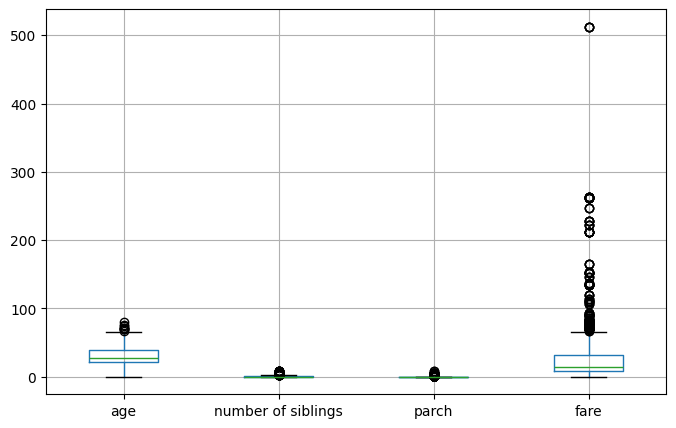

In [41]:
fig, ax = plt.subplots(figsize=(8,5));
titanic_data[data_columns].boxplot();

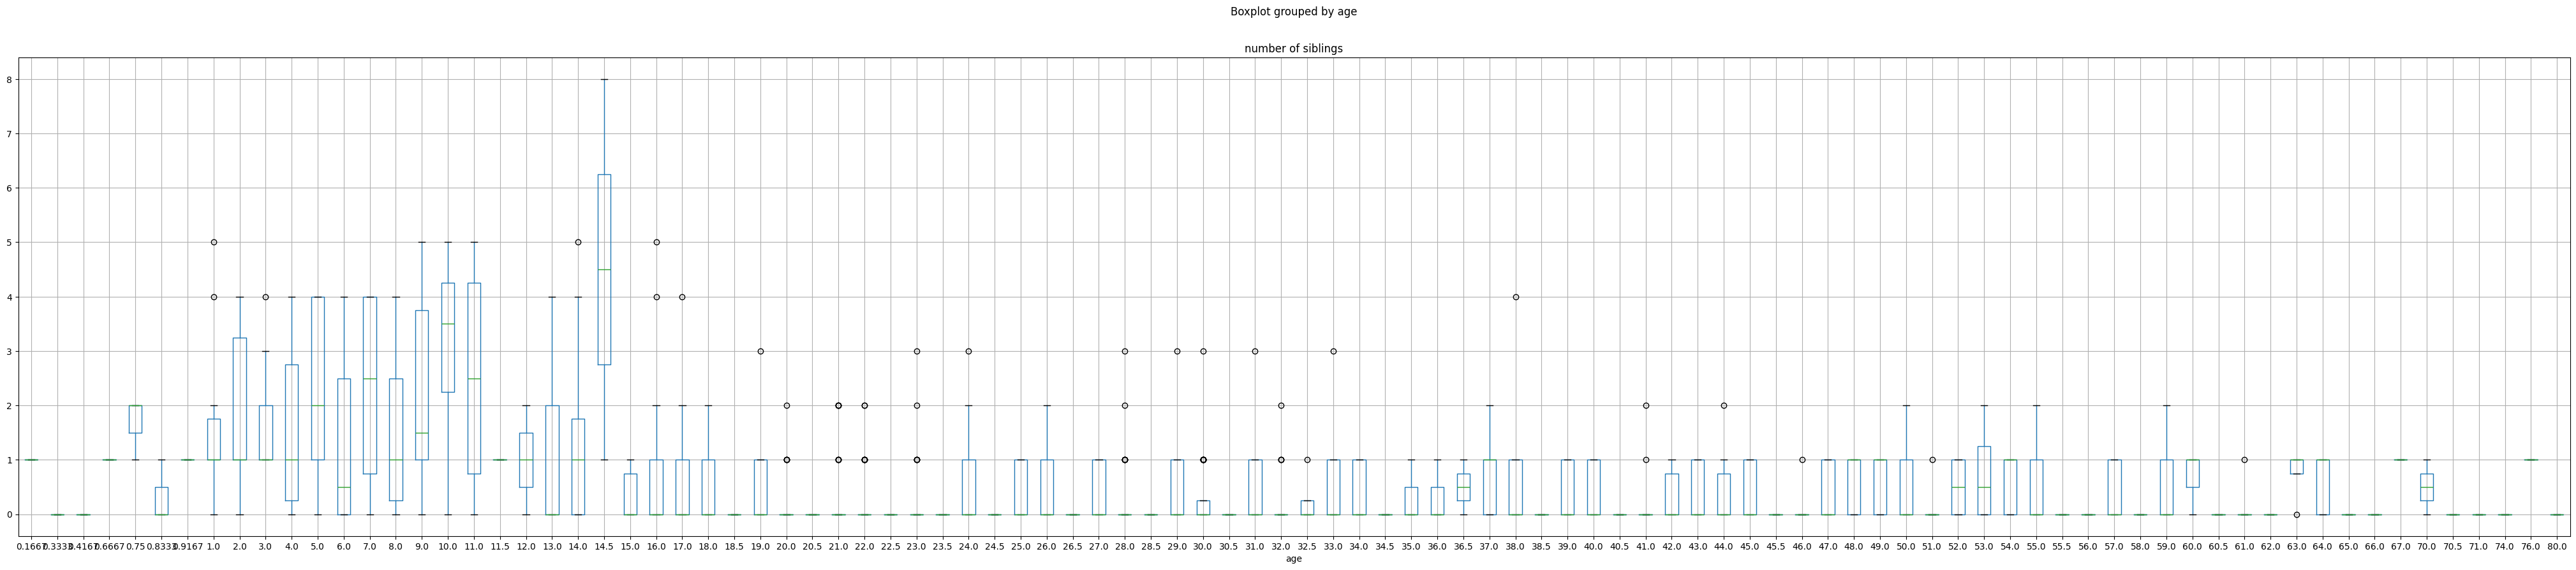

In [56]:
titanic_data.boxplot(column='number of siblings', by='age',figsize=(50,10));
#linea central - mediana
#caja - rango intercuartilico (del 25 al 75%)
#lineas fuera de la caja - valores atípicos

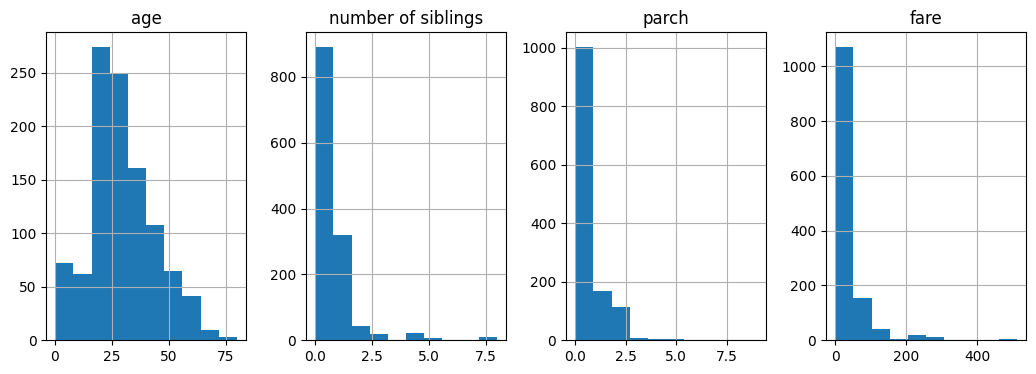

In [49]:
titanic_data[data_columns].hist(figsize=(16,4), layout=(1,5));
#representación simple de los números

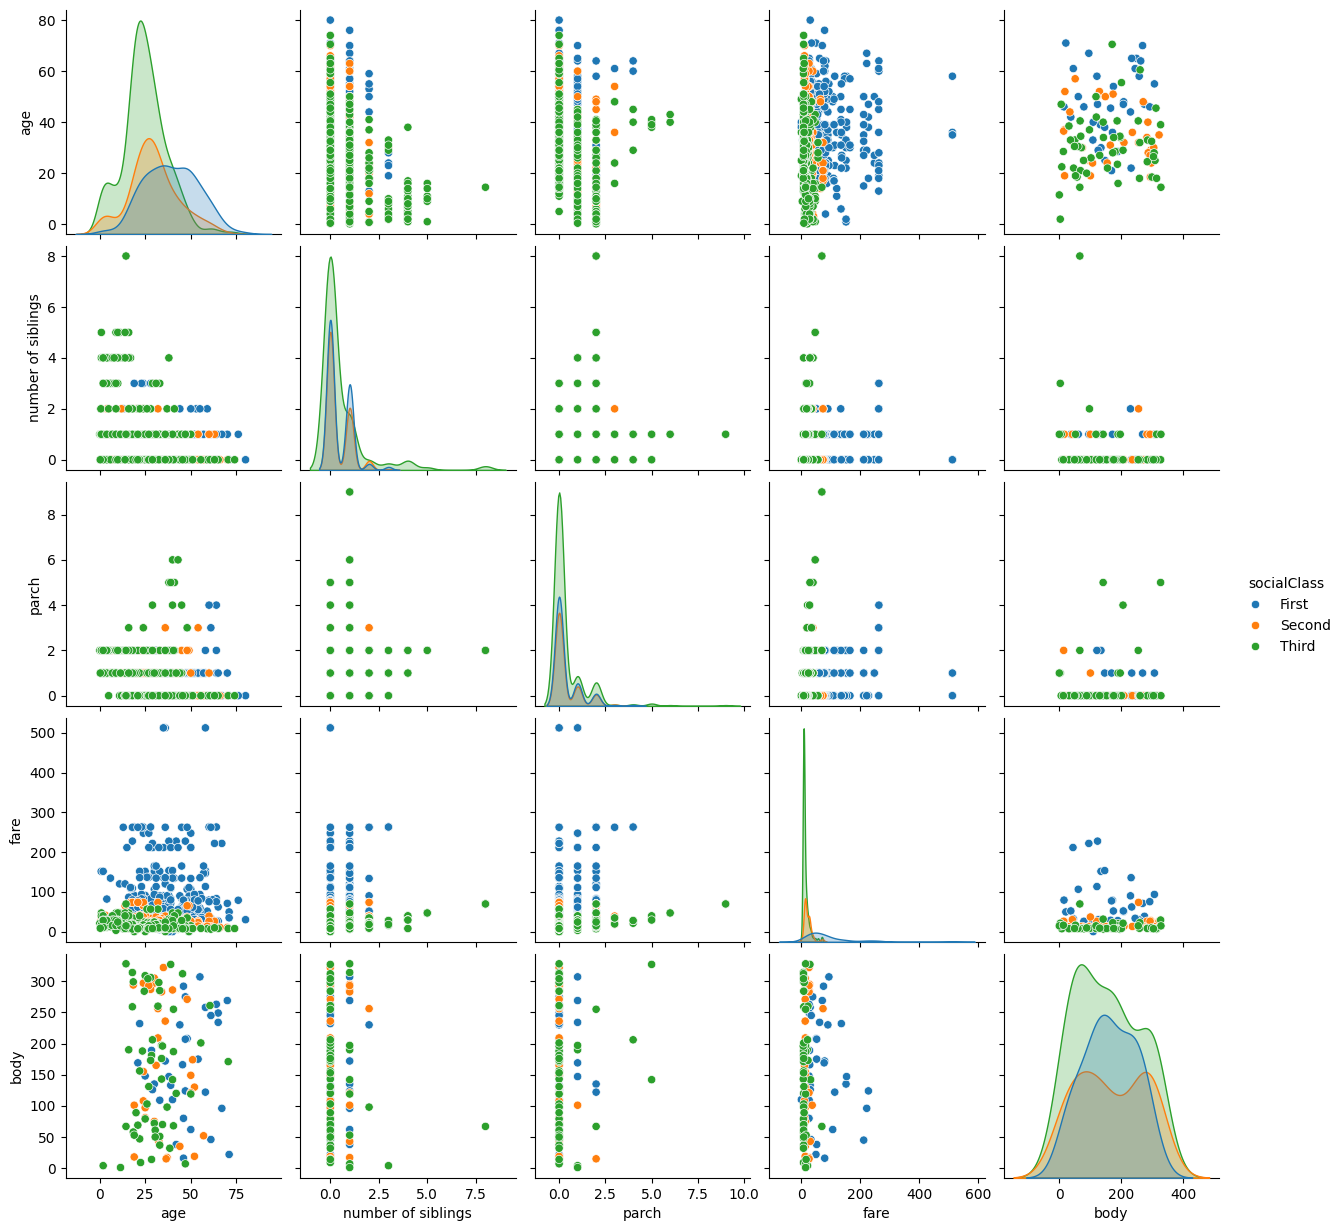

In [54]:
sns.pairplot(titanic_data, hue='socialClass');
# tenemos tres colores representando a cada clase social
# si por ejemplo dos colores están muy mezclados querrá decir que esas variables no son diferenciales para una representación

# En este caso las variables están bastante mezcladas. Hará falta un PCA

**1. Aplicar PCA**

In [73]:
#Aplicamos un PCA para mejorar al visualización de nuestros datos
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# 1. Definimos la columna
data_columns = ['age', 'fare', 'number of siblings', 'parch']

# 2. Creamos la copia
# hace falta crear una limpieza de datos para eliminar los valores nulos. Otra opción sería generar los datos a partir de medias
titanic_clean = titanic_data.dropna(subset=data_columns).copy()
# y la transformamos
scaler = StandardScaler()
titanic_standarized = scaler.fit_transform(titanic_clean[data_columns])


# Procedemos a realizar el PCA :
#resta la media centrando los datos en 0
#divide por al desviacion estandar para que la dispersión sea 1


# 1. Definimos el PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(titanic_standarized)

# 3. Creamos un nuevo DataFrame con los resultados
df_pca = pd.DataFrame(data = pca_results, columns = ['PC1', 'PC2'])

# 4. Añadimos las etiquetas originales para colorear el gráfico después
df_pca['socialClass'] = titanic_clean['socialClass'].values
df_pca['survived'] = titanic_clean['survived'].values
df_pca['class'] = titanic_clean['class'].values
#df_pca['class'] = titanic_clean['class'].values

print(f"Pasajeros analizados tras limpiar nulos: {len(df_pca)}")
print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
df_pca.head()

Pasajeros analizados tras limpiar nulos: 1045
Varianza explicada por cada componente: [0.39123158 0.29766425]


,PC1,PC2,socialClass,survived,class
0,0.260,2.198,First,Yes,First Yes
1,2.818,0.318,First,Yes,First Yes
2,2.792,0.369,First,No,First No
3,2.113,1.688,First,No,First No
4,2.234,1.452,First,No,First No


PCA de scikit-learn  <br>
-explained_variance_ratio_ (varianza por componente) <br>
una array que muestra el % de información en cada eje del PCA.<br>
PC1: si es muy alto, sobre el 65% significa que una sola combinación de las variables explica la mayor parte de las diferencias entre los pasajeros del tianic<br>
-explained_variance_ratio_.cumsum() (varianza acumulada) <br>
suma de los porcentajes anteriores. Ayuda a deducir cuantos porcentajes necesito para visualizar un modelo<br>
Conclusión: si proyectamos en un plano 2D usando únicamente PC1 y PC2 estamos conservando el 70% de la información original (después de la limpieza).

Si usamos 3D ganaríamos un 16% extra de precisión a cambio de una dimensión extra de complejidad

In [72]:
myPCA = PCA().fit(titanic_standarized)

print(myPCA.explained_variance_ratio_)
print(myPCA.explained_variance_ratio_.cumsum())

[0.39123158 0.29766425 0.15871333 0.15239084]
[0.39123158 0.68889583 0.84760916 1.        ]


In [78]:
# 1. Transformamos los datos y nos quedamos solo con las 2 primeras columnas ([:, :2])
datos_2d = myPCA.transform(titanic_standarized)[:, :2]

# 2. Lo pasamos a un DataFrame para que sea fácil de ver y usar
df_pca = pd.DataFrame(datos_2d, columns=['PC1', 'PC2'])

# Vemos el resultado
print(df_pca.head())

     PC1    PC2
0  0.260  2.198
1  2.818  0.318
2  2.792  0.369
3  2.113  1.688
4  2.234  1.452


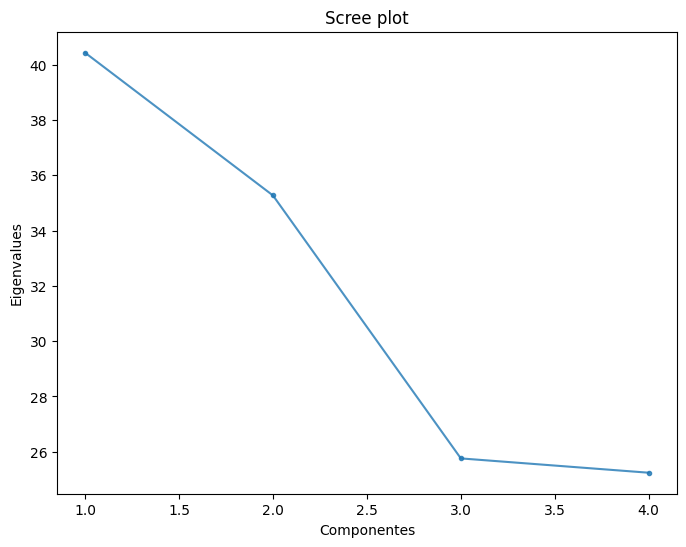

In [74]:
fig = plt.figure(figsize=(8,6));
plt.plot(range(1,len(myPCA.singular_values_ )+1),myPCA.singular_values_ ,alpha=0.8,marker='.');
y_label = plt.ylabel('Eigenvalues');
x_label = plt.xlabel('Componentes');
plt.title('Scree plot');